In [2]:
!unzip -o /content/restaurant_data_package.zip -d /content/

Archive:  /content/restaurant_data_package.zip
  inflating: /content/dataset/restaurant_test_30k.json  
  inflating: /content/dataset/restaurant_train_70k.json  
  inflating: /content/dataset/synthetic_reviews_multi_style_clipped.csv  
  inflating: /content/dataset/embeddings_base_70k.npy  
  inflating: /content/dataset/embeddings_synthetic_multi_style_clipped.npy  


In [3]:
!ls /content/dataset

embeddings_base_70k.npy
embeddings_synthetic_multi_style_clipped.npy
restaurant_test_30k.json
restaurant_train_70k.json
synthetic_reviews_multi_style_clipped.csv


In [4]:
!pip install transformers datasets scikit-learn -q

In [22]:
import pandas as pd
import numpy as np
from datasets import Dataset, DatasetDict

# ── CONFIG ──────────────────────────────────────────────
GUIDE_SIZE   = 3000   # how many real train samples to use as tg_guide
SYNTH_SIZE   = 30000  # how many synthetic samples to use (should be ~10x guide)
RANDOM_STATE = 42
SAMPLES_PER_STAR_GUIDE = GUIDE_SIZE // 5   # 600 per star
SAMPLES_PER_STAR_SYNTH = SYNTH_SIZE // 5   # 6000 per star
# ────────────────────────────────────────────────────────

# --- ts: synthetic reviews + precomputed embeddings ---
synth_df = pd.read_csv('/content/dataset/synthetic_reviews_multi_style_clipped.csv')
synth_df = synth_df.rename(columns={'full_text': 'text', 'stars': 'label'})
synth_df['label'] = synth_df['label'].astype(float)

synth_embs = np.load('/content/dataset/embeddings_synthetic_multi_style_clipped.npy')
assert len(synth_embs) == len(synth_df), "Embedding count doesn't match synthetic df"
synth_df['emb_idx'] = np.arange(len(synth_df))  # track original index for embedding lookup

# Stratified sample of synthetic data
synth_sampled = (
    synth_df.groupby('label', group_keys=False)
            .apply(lambda x: x.sample(
                n=min(SAMPLES_PER_STAR_SYNTH, len(x)),
                random_state=RANDOM_STATE
            ))
            .reset_index(drop=True)
)
synth_embs_sampled = synth_embs[synth_sampled['emb_idx'].values]
synth_sampled = synth_sampled.drop(columns=['emb_idx'])

print(f"Synthetic (ts) distribution:\n{synth_sampled['label'].value_counts().sort_index().to_string()}")

# --- tg_guide: real train reviews + precomputed embeddings (stratified subset) ---
guide_full_df = pd.read_json('/content/dataset/restaurant_train_70k.json', lines=True)
guide_full_df = guide_full_df.rename(columns={'stars': 'label'})
guide_full_df['label'] = guide_full_df['label'].astype(float)

guide_full_embs = np.load('/content/dataset/embeddings_base_70k.npy')
assert len(guide_full_embs) == len(guide_full_df), "Embedding count doesn't match guide df"
guide_full_df['emb_idx'] = np.arange(len(guide_full_df))

# Stratified sample down to GUIDE_SIZE
guide_df = (
    guide_full_df.groupby('label', group_keys=False)
                 .apply(lambda x: x.sample(
                     n=min(SAMPLES_PER_STAR_GUIDE, len(x)),
                     random_state=RANDOM_STATE
                 ))
                 .reset_index(drop=True)
)
guide_embs = guide_full_embs[guide_df['emb_idx'].values]
guide_df = guide_df.drop(columns=['emb_idx'])

print(f"\nGuide (tg_guide) distribution:\n{guide_df['label'].value_counts().sort_index().to_string()}")

# --- tg_eval: real test reviews (locked) ---
eval_df = pd.read_json('/content/dataset/restaurant_test_30k.json', lines=True)
eval_df = eval_df.rename(columns={'stars': 'label'})
eval_df['label'] = eval_df['label'].astype(float)

print(f"\ntg_eval distribution:\n{eval_df['label'].value_counts().sort_index().to_string()}")

# --- ts train/val split (both synthetic) ---
train_df = synth_sampled.sample(frac=0.7, random_state=RANDOM_STATE)
val_df   = synth_sampled.drop(train_df.index)

# Keep track of which synthetic embeddings go to train vs val
train_embs = synth_embs_sampled[train_df.index.values]
val_embs   = synth_embs_sampled[val_df.index.values]

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

# --- HuggingFace DatasetDict (text + label only, embeddings stored as numpy separately) ---
ds = DatasetDict({
    'train':      Dataset.from_pandas(train_df[['text', 'label']]),
    'validation': Dataset.from_pandas(val_df[['text', 'label']]),
    'guide':      Dataset.from_pandas(guide_df[['text', 'label']]),
    'test':       Dataset.from_pandas(eval_df[['text', 'label']].reset_index(drop=True))
})

print(f"\n{'Split':<14}{'Size':<10}")
print("-" * 24)
for split in ['train', 'validation', 'guide', 'test']:
    print(f"{split:<14}{len(ds[split]):<10}")

print(f"\nEmbedding shapes:")
print(f"  train_embs:  {train_embs.shape}")
print(f"  val_embs:    {val_embs.shape}")
print(f"  guide_embs:  {guide_embs.shape}")

/tmp/ipykernel_3991/3933469581.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Synthetic (ts) distribution:
label
1.0    5950
2.0    5949
3.0    5980
4.0    5960
5.0    5952


/tmp/ipykernel_3991/3933469581.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(



Guide (tg_guide) distribution:
label
1.0    600
2.0    600
3.0    600
4.0    600
5.0    600

tg_eval distribution:
label
1.0    6000
2.0    6000
3.0    6000
4.0    6000
5.0    6000

Split         Size      
------------------------
train         20854     
validation    8937      
guide         3000      
test          30000     

Embedding shapes:
  train_embs:  (20854, 384)
  val_embs:    (8937, 384)
  guide_embs:  (3000, 384)


In [23]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from datasets import Dataset, DatasetDict
from sklearn.metrics import cohen_kappa_score
from tqdm.auto import tqdm

MODEL_NAME  = "microsoft/deberta-v3-small"
MAX_LEN     = 256
BATCH_SIZE  = 32
NUM_EPOCHS  = 5
LR          = 2e-5

# Reweighting hyperparameters
TOP_K       = 50    # number of guide neighbors per synthetic sample
TEMPERATURE = 0.1   # sharpness of weight distribution — lower = more peaked

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    cap = torch.cuda.get_device_capability()
    if cap[0] >= 8:
        DTYPE = torch.bfloat16
    else:
        DTYPE = torch.float16
else:
    DTYPE = torch.float32

print(f"Device:     {DEVICE}")
print(f"GPU:        {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"Dtype:      {DTYPE}")
print(f"Top-K:      {TOP_K}")
print(f"Temp:       {TEMPERATURE}")

Device:     cuda
GPU:        NVIDIA A100-SXM4-40GB
Dtype:      torch.bfloat16
Top-K:      50
Temp:       0.1


In [24]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

ds_tokenized = ds.map(tokenize, batched=True, remove_columns=["text"])
ds_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("Tokenization done.")
print(ds_tokenized)

Map:   0%|          | 0/20854 [00:00<?, ? examples/s]

Map:   0%|          | 0/8937 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Tokenization done.
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20854
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8937
    })
    guide: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 30000
    })
})


In [25]:
def compute_qwk(preds, labels):
    # Clip predictions to valid range and round to nearest integer for QWK
    preds_rounded = np.clip(np.round(preds), 1, 5).astype(int)
    labels_int = np.array(labels).astype(int)
    return cohen_kappa_score(labels_int, preds_rounded, weights="quadratic")

# Quick sanity check
print("QWK sanity check:", compute_qwk([1,2,3,4,5], [1,2,3,4,5]))  # should be 1.0

QWK sanity check: 1.0


In [26]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    ignore_mismatched_sizes=True,
    torch_dtype=DTYPE
)
model = model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

sample_weights = np.ones(len(ds_tokenized["train"]))

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(ds_tokenized["train"],      batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader   = DataLoader(ds_tokenized["validation"], batch_size=BATCH_SIZE, shuffle=False)
guide_loader = DataLoader(ds_tokenized["guide"],      batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(ds_tokenized["test"],       batch_size=BATCH_SIZE, shuffle=False)

total_steps = NUM_EPOCHS * len(train_loader)
scheduler = get_scheduler(
    "linear", optimizer=optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

loss_fn = nn.MSELoss()
print(f"Model dtype:      {next(model.parameters()).dtype}")
print(f"Steps per epoch:  {len(train_loader)}")
print(f"Total steps:      {total_steps}")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias         

Model dtype:      torch.bfloat16
Steps per epoch:  652
Total steps:      3260


In [27]:
print("Precomputing similarity matrix...")
train_embs_norm = train_embs / np.linalg.norm(train_embs, axis=1, keepdims=True)
guide_embs_norm = guide_embs / np.linalg.norm(guide_embs, axis=1, keepdims=True)

sim_matrix = train_embs_norm @ guide_embs_norm.T
print(f"  sim_matrix shape: {sim_matrix.shape}")
print(f"  sim range: [{sim_matrix.min():.3f}, {sim_matrix.max():.3f}]")

# Top-K masking — keep only top K similarities per synthetic sample
print(f"Applying top-{TOP_K} mask...")
topk_matrix = np.zeros_like(sim_matrix)
topk_indices = np.argpartition(sim_matrix, -TOP_K, axis=1)[:, -TOP_K:]
rows = np.arange(len(sim_matrix))[:, None]
topk_matrix[rows, topk_indices] = sim_matrix[rows, topk_indices]

# ── NO temperature scaling ──
# Similarities are already spread 0-0.9, exp() just causes blowup
# Instead: row-normalize so each synthetic sample's affinities sum to 1
# This means: weight_i = sum over guide of (normalized_affinity * guide_loss)
# which is a proper weighted average of guide losses
row_sums = topk_matrix.sum(axis=1, keepdims=True)
row_sums = np.where(row_sums == 0, 1, row_sums)  # avoid div by zero
topk_matrix = topk_matrix / row_sums

print(f"  Row-normalized — each row sums to 1.0")
print(f"  Nonzero sim range: [{sim_matrix[sim_matrix>0].min():.4f}, "
      f"{sim_matrix[sim_matrix>0].max():.4f}]")

# Quick sanity — with uniform guide losses, all weights should be ~equal
dummy = np.ones(guide_embs.shape[0])
test_weights = topk_matrix @ dummy
print(f"\nSanity check (uniform guide losses → all weights should be 1.0):")
print(f"  Min: {test_weights.min():.4f} | Max: {test_weights.max():.4f} "
      f"| Mean: {test_weights.mean():.4f}")
# Should print min≈max≈1.0 — confirms normalization is correct

Precomputing similarity matrix...
  sim_matrix shape: (20854, 3000)
  sim range: [-0.164, 0.906]
Applying top-50 mask...
  Row-normalized — each row sums to 1.0
  Nonzero sim range: [0.0000, 0.9065]

Sanity check (uniform guide losses → all weights should be 1.0):
  Min: 1.0000 | Max: 1.0000 | Mean: 1.0000


=== RAW SIMILARITY STATS (before temperature) ===
Min:    0.0000
Max:    0.9065
Mean:   0.3809
Std:    0.1161
Percentiles:
  p  1: 0.1017
  p  5: 0.1835
  p 25: 0.3037
  p 50: 0.3838
  p 75: 0.4609
  p 95: 0.5676
  p 99: 0.6392

=== WEIGHT DISTRIBUTION (uniform guide losses) ===
Min:    1.0000
Max:    1.0000
Mean:   1.0000
Std:    0.0000
Ratio max/min: 1.0x
Percentiles:
  p  1: 1.0000
  p  5: 1.0000
  p 25: 1.0000
  p 50: 1.0000
  p 75: 1.0000
  p 95: 1.0000
  p 99: 1.0000

Samples with weight >10x mean: 0 (0.0%)
Samples with weight <0.1x mean: 0


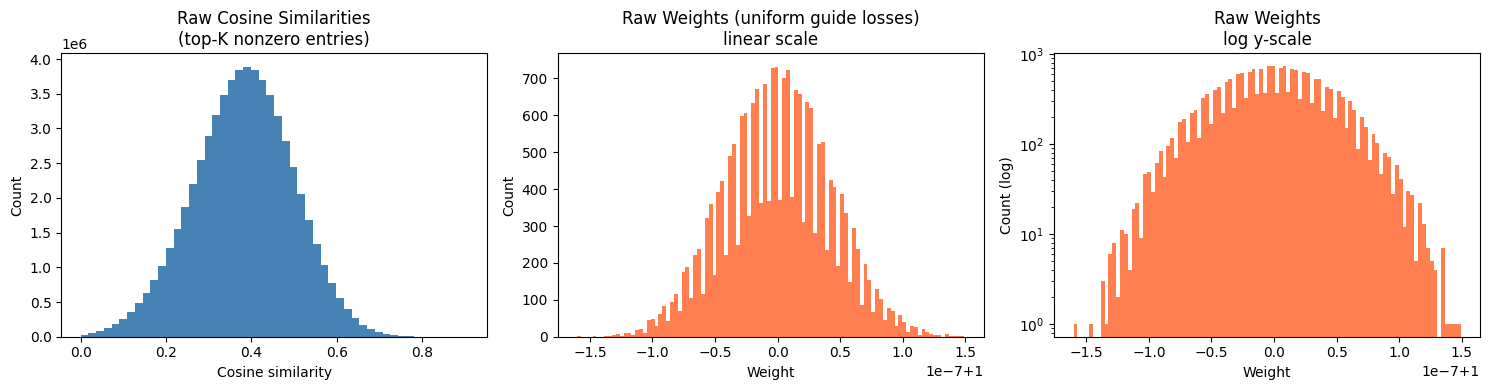

Saved to /content/weight_distribution.png


In [28]:
import matplotlib.pyplot as plt

# ── Raw similarity stats ──────────────────────────────────────────────
print("=== RAW SIMILARITY STATS (before temperature) ===")
nonzero_sims = sim_matrix[sim_matrix > 0]
print(f"Min:    {nonzero_sims.min():.4f}")
print(f"Max:    {nonzero_sims.max():.4f}")
print(f"Mean:   {nonzero_sims.mean():.4f}")
print(f"Std:    {nonzero_sims.std():.4f}")
print(f"Percentiles:")
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"  p{p:>3}: {np.percentile(nonzero_sims, p):.4f}")

# ── Weight distribution after temp scaling ────────────────────────────
# Compute raw weights using uniform guide losses = 1.0 (just to inspect shape)
dummy_guide_losses = np.ones(guide_embs.shape[0])
raw_weights = topk_matrix @ dummy_guide_losses

print("\n=== WEIGHT DISTRIBUTION (uniform guide losses) ===")
print(f"Min:    {raw_weights.min():.4f}")
print(f"Max:    {raw_weights.max():.4f}")
print(f"Mean:   {raw_weights.mean():.4f}")
print(f"Std:    {raw_weights.std():.4f}")
print(f"Ratio max/min: {raw_weights.max()/raw_weights.min():.1f}x")
print(f"Percentiles:")
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"  p{p:>3}: {np.percentile(raw_weights, p):.4f}")

# How many samples get >10x the mean weight?
mean_w = raw_weights.mean()
dominated = (raw_weights > 10 * mean_w).sum()
print(f"\nSamples with weight >10x mean: {dominated} ({100*dominated/len(raw_weights):.1f}%)")
print(f"Samples with weight <0.1x mean: {(raw_weights < 0.1 * mean_w).sum()}")

# ── Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Raw similarity distribution
axes[0].hist(nonzero_sims, bins=50, color='steelblue', edgecolor='none')
axes[0].set_title("Raw Cosine Similarities\n(top-K nonzero entries)")
axes[0].set_xlabel("Cosine similarity")
axes[0].set_ylabel("Count")

# 2. Weight distribution (log scale to see the tail)
axes[1].hist(raw_weights, bins=100, color='coral', edgecolor='none')
axes[1].set_title("Raw Weights (uniform guide losses)\nlinear scale")
axes[1].set_xlabel("Weight")
axes[1].set_ylabel("Count")

# 3. Same but log scale
axes[2].hist(raw_weights, bins=100, color='coral', edgecolor='none', log=True)
axes[2].set_title("Raw Weights\nlog y-scale")
axes[2].set_xlabel("Weight")
axes[2].set_ylabel("Count (log)")

plt.tight_layout()
plt.savefig("/content/weight_distribution.png", dpi=150)
plt.show()
print("Saved to /content/weight_distribution.png")

In [29]:
def evaluate(loader, split_name="val"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["label"].float().to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = outputs.logits.squeeze(-1)

            # cast to float32 before moving to cpu — fixes bf16/fp16 numpy error
            all_preds.extend(preds.float().cpu().numpy())
            all_labels.extend(labels.float().cpu().numpy())

    qwk = compute_qwk(all_preds, all_labels)
    mse = np.mean((np.array(all_preds) - np.array(all_labels)) ** 2)
    print(f"  [{split_name}] QWK: {qwk:.4f} | MSE: {mse:.4f}")
    return qwk, all_preds, all_labels

In [30]:
import os, json

SAVE_DIR = "/content/reweighted_model_v1"
os.makedirs(SAVE_DIR, exist_ok=True)

history = {
    "train_loss":     [],
    "synth_val_qwk":  [],
    "real_guide_qwk": [],
    "real_test_qwk":  [],
    "weight_stats":   []
}

best_test_qwk = -1
best_epoch    = -1

for epoch in range(NUM_EPOCHS):

    # ── REWEIGHTING STEP ──────────────────────────────────────────────────────
    if epoch > 0:
        print(f"\n  Computing guide losses for reweighting...")
        model.eval()
        guide_losses = []

        with torch.no_grad():
            for batch in guide_loader:
                input_ids      = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                labels         = batch["label"].to(DEVICE).to(DTYPE)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds   = outputs.logits.squeeze(-1).to(DTYPE)

                # Per-sample loss — shape: [batch_size]
                per_sample_loss = (preds - labels) ** 2
                guide_losses.extend(per_sample_loss.float().cpu().numpy())

        guide_losses = np.array(guide_losses)  # shape: [n_guide]

        # Transfer guide signal to synthetic samples via row-normalized sim matrix
        raw_weights = topk_matrix @ guide_losses  # shape: [n_train]

        # Gentle percentile clip to handle outliers
        p_low  = np.percentile(raw_weights, 10)
        p_high = np.percentile(raw_weights, 90)
        raw_weights = np.clip(raw_weights, p_low, p_high)

        # Normalize so weights sum to n_train — expected samples per epoch unchanged
        sample_weights = raw_weights / raw_weights.sum() * len(raw_weights)

        # Log weight stats
        stats = {
            "epoch":           epoch,
            "w_mean":          float(sample_weights.mean()),
            "w_std":           float(sample_weights.std()),
            "w_min":           float(sample_weights.min()),
            "w_max":           float(sample_weights.max()),
            "guide_loss_mean": float(guide_losses.mean()),
            "guide_loss_std":  float(guide_losses.std()),
            "guide_loss_min":  float(guide_losses.min()),
            "guide_loss_max":  float(guide_losses.max()),
        }
        history["weight_stats"].append(stats)

        print(f"  Guide losses  — mean: {stats['guide_loss_mean']:.4f} | "
              f"std: {stats['guide_loss_std']:.4f} | "
              f"min: {stats['guide_loss_min']:.4f} | "
              f"max: {stats['guide_loss_max']:.4f}")
        print(f"  Sample weights — mean: {stats['w_mean']:.4f} | "
              f"std: {stats['w_std']:.4f} | "
              f"min: {stats['w_min']:.4f} | "
              f"max: {stats['w_max']:.4f}")

        # Star-level breakdown — see which star ratings are driving high losses
        guide_labels = np.array(ds["guide"]["label"])
        print(f"  Per-star guide loss:")
        for star in [1.0, 2.0, 3.0, 4.0, 5.0]:
            mask = guide_labels == star
            if mask.sum() > 0:
                print(f"    {int(star)}★  mean loss: {guide_losses[mask].mean():.4f} "
                      f"| n: {mask.sum()}")

        # Rebuild sampler and loader with new weights
        train_sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        train_loader = DataLoader(
            ds_tokenized["train"],
            batch_size=BATCH_SIZE,
            sampler=train_sampler
        )
    # ─────────────────────────────────────────────────────────────────────────

    # ── TRAINING STEP ─────────────────────────────────────────────────────────
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch in loop:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["label"].to(DEVICE).to(DTYPE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = outputs.logits.squeeze(-1).to(DTYPE)

        loss = loss_fn(preds, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")
    # ─────────────────────────────────────────────────────────────────────────

    avg_loss = total_loss / len(train_loader)
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} | Avg Train Loss: {avg_loss:.4f}")

    synth_val_qwk,  _, _ = evaluate(val_loader,   "synth_val ")
    real_guide_qwk, _, _ = evaluate(guide_loader, "real_guide")
    real_test_qwk,  _, _ = evaluate(test_loader,  "real_test ")

    history["train_loss"].append(avg_loss)
    history["synth_val_qwk"].append(synth_val_qwk)
    history["real_guide_qwk"].append(real_guide_qwk)
    history["real_test_qwk"].append(real_test_qwk)

    if real_test_qwk > best_test_qwk:
        best_test_qwk = real_test_qwk
        best_epoch    = epoch + 1
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f"  ✓ Best model saved (test QWK: {best_test_qwk:.4f})")

# ── SAVE HISTORY ──────────────────────────────────────────────────────────────
with open(f"{SAVE_DIR}/history.json", "w") as f:
    json.dump(history, f, indent=2)

# ── FINAL SUMMARY ─────────────────────────────────────────────────────────────
print(f"\n=== V2 REWEIGHTING COMPLETE ===")
print(f"Best real_test QWK: {best_test_qwk:.4f} at epoch {best_epoch}")

print(f"\n{'Epoch':<8}{'Train Loss':<14}{'Synth Val':<14}{'Real Guide':<14}{'Real Test':<14}")
print("-" * 60)
for i in range(NUM_EPOCHS):
    marker = " ←" if (i + 1) == best_epoch else ""
    print(f"{i+1:<8}{history['train_loss'][i]:<14.4f}{history['synth_val_qwk'][i]:<14.4f}"
          f"{history['real_guide_qwk'][i]:<14.4f}{history['real_test_qwk'][i]:<14.4f}{marker}")

print(f"\nBaseline best: 0.8051 | V2 best: {best_test_qwk:.4f} | "
      f"Delta: {best_test_qwk - 0.8051:+.4f}")

# ── WEIGHT EVOLUTION SUMMARY ──────────────────────────────────────────────────
if history["weight_stats"]:
    print(f"\nWeight evolution across epochs:")
    print(f"{'Epoch':<8}{'Guide Loss Mean':<18}{'W Mean':<12}{'W Std':<12}{'W Max':<12}")
    print("-" * 60)
    for s in history["weight_stats"]:
        print(f"{s['epoch']:<8}{s['guide_loss_mean']:<18.4f}"
              f"{s['w_mean']:<12.4f}{s['w_std']:<12.4f}{s['w_max']:<12.4f}")

Epoch 1/5:   0%|          | 0/652 [00:00<?, ?it/s]


Epoch 1/5 | Avg Train Loss: 4.0742
  [synth_val ] QWK: 0.9291 | MSE: 0.2550
  [real_guide] QWK: 0.7675 | MSE: 0.7445
  [real_test ] QWK: 0.7745 | MSE: 0.7266


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (test QWK: 0.7745)

  Computing guide losses for reweighting...
  Guide losses  — mean: 0.7443 | std: 1.2077 | min: 0.0000 | max: 15.2500
  Sample weights — mean: 1.0000 | std: 0.2101 | min: 0.6872 | max: 1.3345
  Per-star guide loss:
    1★  mean loss: 0.5239 | n: 600
    2★  mean loss: 0.3474 | n: 600
    3★  mean loss: 0.7464 | n: 600
    4★  mean loss: 0.8758 | n: 600
    5★  mean loss: 1.2280 | n: 600


Epoch 2/5:   0%|          | 0/652 [00:00<?, ?it/s]

...


Epoch 4/5 | Avg Train Loss: 0.2114
  [synth_val ] QWK: 0.9316 | MSE: 0.2642
  [real_guide] QWK: 0.8050 | MSE: 0.6341
  [real_test ] QWK: 0.8082 | MSE: 0.6208


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (test QWK: 0.8082)

  Computing guide losses for reweighting...
  Guide losses  — mean: 0.6339 | std: 1.0934 | min: 0.0000 | max: 14.6250
  Sample weights — mean: 1.0000 | std: 0.2266 | min: 0.6750 | max: 1.3766
  Per-star guide loss:
    1★  mean loss: 0.6039 | n: 600
    2★  mean loss: 0.3563 | n: 600
    3★  mean loss: 0.6591 | n: 600
    4★  mean loss: 0.6924 | n: 600
    5★  mean loss: 0.8577 | n: 600


Epoch 5/5:   0%|          | 0/652 [00:00<?, ?it/s]


Epoch 5/5 | Avg Train Loss: 0.2160
  [synth_val ] QWK: 0.9310 | MSE: 0.2641
  [real_guide] QWK: 0.8044 | MSE: 0.6323
  [real_test ] QWK: 0.8080 | MSE: 0.6188

=== V2 REWEIGHTING COMPLETE ===
Best real_test QWK: 0.8082 at epoch 4

Epoch   Train Loss    Synth Val     Real Guide    Real Test     
------------------------------------------------------------
1       4.0742        0.9291        0.7675        0.7745        
2       0.2525        0.9361        0.7949        0.8004        
3       0.2227        0.9317        0.7980        0.8038        
4       0.2114        0.9316        0.8050        0.8082         ←
5       0.2160        0.9310        0.8044        0.8080        

Baseline best: 0.8051 | V2 best: 0.8082 | Delta: +0.0031

Weight evolution across epochs:
Epoch   Guide Loss Mean   W Mean      W Std       W Max       
------------------------------------------------------------
1       0.7443            1.0000      0.2101      1.3345      
2       0.6697            1.0000      

In [31]:
!zip /content/baseline_model.zip -r /content/baseline_model

updating: content/baseline_model/ (stored 0%)
updating: content/baseline_model/model.safetensors (deflated 21%)
updating: content/baseline_model/config.json (deflated 55%)
updating: content/baseline_model/tokenizer_config.json (deflated 48%)
updating: content/baseline_model/tokenizer.json (deflated 79%)
updating: content/baseline_model/history.json (deflated 52%)
